In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

**<font size="6" color="red">ch01.NLTK자연어처리 패키지</font>**
```
자연어처리 : 텍스트 전처리, 단어의 빈도수 측정, 문서유사도 측정, 연관분석,딥러닝,
        워드임배딩, 텍스트분류, 어휘 데이터 베이스 사용, 감정분석, 분류분석 
```

# 1.NLTK패키지
- 텍스트 전처리, 단어빈도수 측정 : 토큰화(문장, 어절, 형태소 나누기), 정규표현식을 이용한 불용어 처리, 어간추출,
- 품사태깅 : 단어별 품사를 식별

```
pip install nltk==3.7
```

In [46]:
import nltk

In [47]:
# 말뭉치 다운로더 받을 폴더(book선택후 다운로드)
# c:/nltk_data, e:/nltk_data,c:/Users/내컴퓨터이름/nltk_data
# c:/Users/내컴퓨터이름/anacond3/nltk_data
# c:/Users/내컴퓨터이름/AppData/nltk_data
# c:/Users/내컴퓨터이름/anacond3/lib/nltk_data
# c:/Users/내컴퓨터이름/anacond3/share/nltk_data
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [48]:
# 말뭉치 리스트
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [104]:
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:30])
print(type(emma))
print('글자수:',len(emma))

[Emma by Jane Austen 1816]

VO
<class 'str'>
글자수: 887071


In [106]:
# sent_tokenize() 문장단위로 쪼갠 list 반환
from nltk.tokenize import sent_tokenize
sent_tokens = sent_tokenize(emma)
print('문장수:',len(sent_tokens))
print('첫문장:',sent_tokens[0])

문장수: 7456
첫문장: [Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.


In [107]:
# word_tokenize() : 단어 단위로 쪼갠 list반환
from nltk.tokenize import word_tokenize
print(word_tokenize(sent_tokens[0]))

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']


In [108]:
# gexpTokenizer 클래스 : 정규표현식을 이용한 토큰화 작업을 하기 위함 
from nltk.tokenize import RegexpTokenizer
ret = RegexpTokenizer('\d+') # [0-9]+
digits = ret.tokenize(emma)
print(digits)
ret1 = RegexpTokenizer('\w+') #[a-zA-Z0-9]+
words = ret1.tokenize(sent_tokens[0])
print(words)
ret2 = RegexpTokenizer('[a-zA-Z]+') # 해당 정규표현식에 맞는 단어만 추출
words2 = ret2.tokenize(sent_tokens[0])
print(words2)

['1816', '8', '23', '28', '28', '24', '7', '10', '000', '10', '000', '26']
['Emma', 'by', 'Jane', 'Austen', '1816', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']
['Emma', 'by', 'Jane', 'Austen', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']


# 2. 형태소(의미가 있는 가장 작은 단위)분석
- 자연어 처리의기본 : 형태소분석과 품사태깅 - 어간추출(Stemmer), 품사태깅(pos_tag)

In [109]:
words = ['sending', 'cooking', 'files', 'lives', 'crying', 'dying']
# 어간추출1 PorterStemmer
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer
pst = PorterStemmer()
# pst.stem(words[0])
[pst.stem(word) for word in words]

['send', 'cook', 'file', 'live', 'cri', 'die']

In [110]:
# 어간추출2 : LancasterStemmer
lst = LancasterStemmer()
[lst.stem(word) for word in words]

['send', 'cook', 'fil', 'liv', 'cry', 'dying']

In [111]:
# 어간추출3 : RegexpStemmer
rst = RegexpStemmer('ing')
[rst.stem(word) for word in words]

['send', 'cook', 'files', 'lives', 'cry', 'dy']

# 3. 품사태깅
- https://dbrang.tistory.com/1139 

In [112]:
from nltk.tag import pos_tag
tagged_list = pos_tag(word_tokenize(sent_tokens[0]))
print('품사태깅 결과:',tagged_list)

품사태깅 결과: [('[', 'NNS'), ('Emma', 'NNP'), ('by', 'IN'), ('Jane', 'NNP'), ('Austen', 'NNP'), ('1816', 'CD'), (']', 'NNP'), ('VOLUME', 'NNP'), ('I', 'PRP'), ('CHAPTER', 'VBP'), ('I', 'PRP'), ('Emma', 'NNP'), ('Woodhouse', 'NNP'), (',', ','), ('handsome', 'NN'), (',', ','), ('clever', 'NN'), (',', ','), ('and', 'CC'), ('rich', 'JJ'), (',', ','), ('with', 'IN'), ('a', 'DT'), ('comfortable', 'JJ'), ('home', 'NN'), ('and', 'CC'), ('happy', 'JJ'), ('disposition', 'NN'), (',', ','), ('seemed', 'VBD'), ('to', 'TO'), ('unite', 'VB'), ('some', 'DT'), ('of', 'IN'), ('the', 'DT'), ('best', 'JJS'), ('blessings', 'NNS'), ('of', 'IN'), ('existence', 'NN'), (';', ':'), ('and', 'CC'), ('had', 'VBD'), ('lived', 'VBN'), ('nearly', 'RB'), ('twenty-one', 'CD'), ('years', 'NNS'), ('in', 'IN'), ('the', 'DT'), ('world', 'NN'), ('with', 'IN'), ('very', 'RB'), ('little', 'JJ'), ('to', 'TO'), ('distress', 'VB'), ('or', 'CC'), ('vex', 'VB'), ('her', 'PRP'), ('.', '.')]


In [113]:
# 명사만 추출 : NN, NNP, NNS, NNPS
nouns_list = []
for word,tag in tagged_list:
#     if (tag=='NN') | (tag=='NNS') |(tag=='NNP') |(tag=='NNPS')
      if tag in ['NN','NNS','NNP','NNPS']:  
#       if tag.find('NN')!=-1:
        nouns_list.append(word)
print(nouns_list)

['[', 'Emma', 'Jane', 'Austen', ']', 'VOLUME', 'Emma', 'Woodhouse', 'handsome', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world']


In [114]:
nouns_list = [word for word, tag in tagged_list if tag in ['NN','NNS','NNP','NNPS']]
print(nouns_list)

['[', 'Emma', 'Jane', 'Austen', ']', 'VOLUME', 'Emma', 'Woodhouse', 'handsome', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world']


## Quiz. emma 소설안에서 

1. 특수문자가 들어가지않은 3글자 이상의 단어만 (RegexpTokenizer)만 추출해서 품사태깅(pos_tag)하세요

2. 'Emma'단어가 몇번 등장했는지,품사태깅이 어떤 품사들(set)로 되어있는지 모구 출력하시오.

3. 내가 원하는 품사(명사:NN,NNS,NNP,NNPS)만 뽑아 등장하는 명사의 종류갯수 츨력

In [115]:
#1.특수문자가 들어가지않은 3글자 이상의 단어만 (RegexpTokenizer)만 추출해서 품사태깅(pos_tag)하세요
# import nltk
# from nltk.tokenize import RegexpTokenizer
# from nltk.tag import pos_tag
# emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
# ret = RegexpTokenizer('\w{3,}') 
# words = ret.tokenize(emma)
# tagged_list = pos_tag(words)
# print('글자수:',len(emma))
# print('단어 출현 수:',len(words),len(tagged_list))
# print('단어 종류 수(겹치는단어제외):',len(set(word)),len(set(tagged_list)))


import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
ret = RegexpTokenizer('\w{3,}')
words = ret.tokenize(emma)
tagged_list = pos_tag(words)
print('글자수 :', len(emma))
print('단어 출현 수 :', len(words), len(tagged_list))
print('단어 종류 수(겹치는 단어 제외) :', len(set(words)), len(set(tagged_list)))

글자수 : 887071
단어 출현 수 : 123877 123877
단어 종류 수(겹치는 단어 제외) : 7630 11678


In [116]:
tagged_list[:10]

[('Emma', 'NNP'),
 ('Jane', 'NNP'),
 ('Austen', 'NNP'),
 ('1816', 'CD'),
 ('VOLUME', 'NNP'),
 ('CHAPTER', 'NNP'),
 ('Emma', 'NNP'),
 ('Woodhouse', 'NNP'),
 ('handsome', 'VBD'),
 ('clever', 'NN')]

In [117]:
# 2번은 이렇게 하면 안 됨
ret_emma = RegexpTokenizer('Emma')
emmas = ret_emma.tokenize(emma)
emmas_tags = pos_tag(emmas)
print(len(emmas))
print(set([tag for word, tag in emmas_tags]))

865
{'NNP'}


In [118]:
#2.'Emma' 단어가 몇번 등장했는지, 품사태깅이 어떤 품사들(NNP, NN, JJ, ...)로 되어 있는지 모두 출력하시오.
# from nltk.tag import pos_tag
# tagged_words = pos_tag(words)
# emma_count = words.count('Emma')
# emma_pos = set(tag for word, tag in tagged_words if word =='Emma')
# print('Emma 등장횟수:',emma_count)
# print('Emma 품사:',emma_pos)

tags = [] # 품사들 저장할 list
for word, tag in tagged_list:
    if word == 'Emma':
        tags.append(tag)
cnt = len(tags)
pos = set(tags)
print('Emma 등장 횟수 :', cnt)
print('분류된 품사들 :', pos)

Emma 등장 횟수 : 865
분류된 품사들 : {'VBD', 'VBP', 'JJ', 'VB', 'RB', 'NN', 'VBN', 'NNS', 'NNPS', 'NNP'}


In [119]:
# 2. 'Emma' 단어가 몇번 등장했는지, 품사태깅이 어떤 품사들(NNP, NN, JJ, ...)로 되어 있는지 모두 출력하시오.
tags = [tag for word, tag in tagged_list if word=='Emma']
cnt = len(tags)
pos = set(tags)
print('Emma 등장 횟수 :', cnt)
print('분류된 품사들 :', pos)

Emma 등장 횟수 : 865
분류된 품사들 : {'VBD', 'VBP', 'JJ', 'VB', 'RB', 'NN', 'VBN', 'NNS', 'NNPS', 'NNP'}


In [120]:
# Emma를 NNP는 몇번 태깅되었는지, NNS는 몇번 태깅되었는지 등 각 품사별 태깅이 몇번 되었는지(Series이용)
import pandas as pd
pos_cnt = pd.Series([0]*len(pos), index=pos)
for word, tag in tagged_list:
    if word == 'Emma':
        pos_cnt[tag] += 1
pos_cnt.sort_values(ascending=False) # 내림차순

NNP     838
NN        7
VB        5
VBP       4
JJ        4
NNS       2
NNPS      2
VBD       1
RB        1
VBN       1
dtype: int64

In [121]:
# Emma를 NNP는 몇번 태깅되었는지, NNS는 몇번 태깅되었는지 등 각 품사별 태깅이 몇번 되었는지(dict이용)
pos_cnt = dict()
for word, tag in tagged_list:
    if word == 'Emma':
        if tag in pos_cnt:
            pos_cnt[tag] += 1
        else:
            pos_cnt[tag] = 1
# pos_cnt['NNP'] = 1
# pos_cnt['NN'] = 1
# pos_cnt['NNP'] += 1
print(pos_cnt)

{'NNP': 838, 'VBP': 4, 'JJ': 4, 'VB': 5, 'NNS': 2, 'RB': 1, 'NN': 7, 'NNPS': 2, 'VBN': 1, 'VBD': 1}


In [122]:
# pos_cnt.items()
sorted(pos_cnt.items(), key=lambda x:x[1], reverse=True)

[('NNP', 838),
 ('NN', 7),
 ('VB', 5),
 ('VBP', 4),
 ('JJ', 4),
 ('NNS', 2),
 ('NNPS', 2),
 ('RB', 1),
 ('VBN', 1),
 ('VBD', 1)]

In [123]:
# 3. 내가 원하는 품사(명사:NN,NNS,NNP,NNPS)만 뽑아 등장하는 명사의 종류갯수 츨력
# nouns_list = []
# for word,tag in tagged_list:
#     if tag in ['NN','NNS','NNP','NNPS']:
#         nouns_list.append(word)
# print('명사목록:',nouns_list)
# print('명사의 종류:',set(nouns_list))
# print('명사의 종류 갯수:',len(set(sent_tokens))

nouns_list = []
noun_tags = ["NN", "NNS", "NNP", "NNPS"]
for word, tag in tagged_list:
    if tag in noun_tags:
        nouns_list.append(word)
nouns_list = [word for word, tag in tagged_list if tag in noun_tags]
print('명사가 나온 횟수 :', len(nouns_list))
print('출현한 명사 수(반복제거) : ', len(set(nouns_list)))
print('한단어가 나오는 평균빈도수 :',
     len(nouns_list) / len(set(nouns_list)))

명사가 나온 횟수 : 30781
출현한 명사 수(반복제거) :  4165
한단어가 나오는 평균빈도수 : 7.3903961584633855


# 4. 최빈 단어 시각화

In [124]:
print(nouns_list[:10])

['Emma', 'Jane', 'Austen', 'VOLUME', 'CHAPTER', 'Emma', 'Woodhouse', 'clever', 'home', 'disposition']


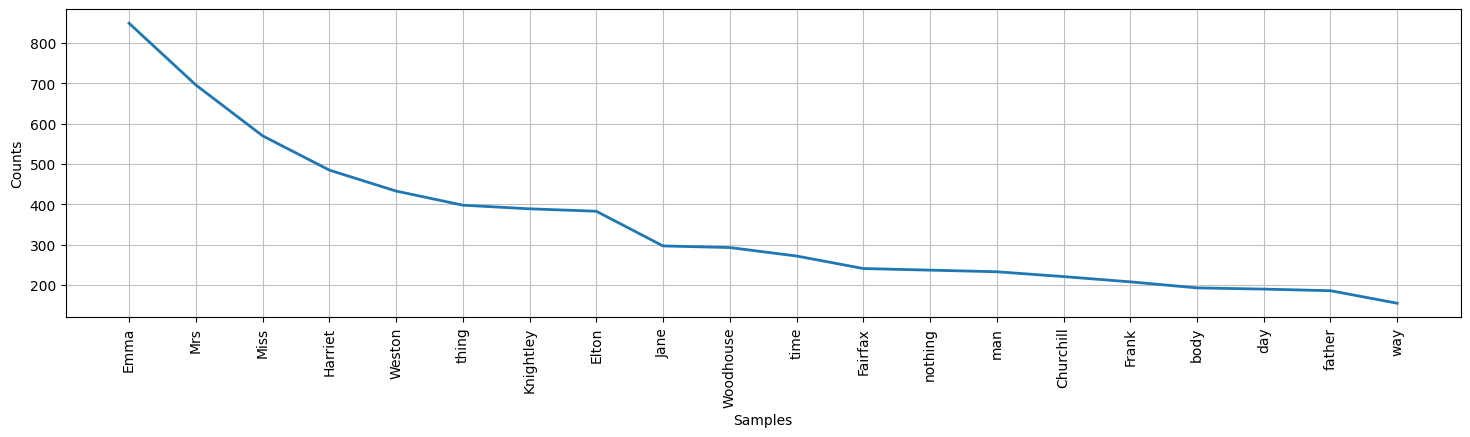

In [125]:
import matplotlib.pyplot as plt
from nltk import Text
# Text : 단어리스트와 관련된 빈도분석이나 단어검색을 쉽게 처리할수있는 클래스
emma_text = Text(nouns_list)
plt.figure(figsize=(18,4))
emma_text.plot(20)
plt.show()

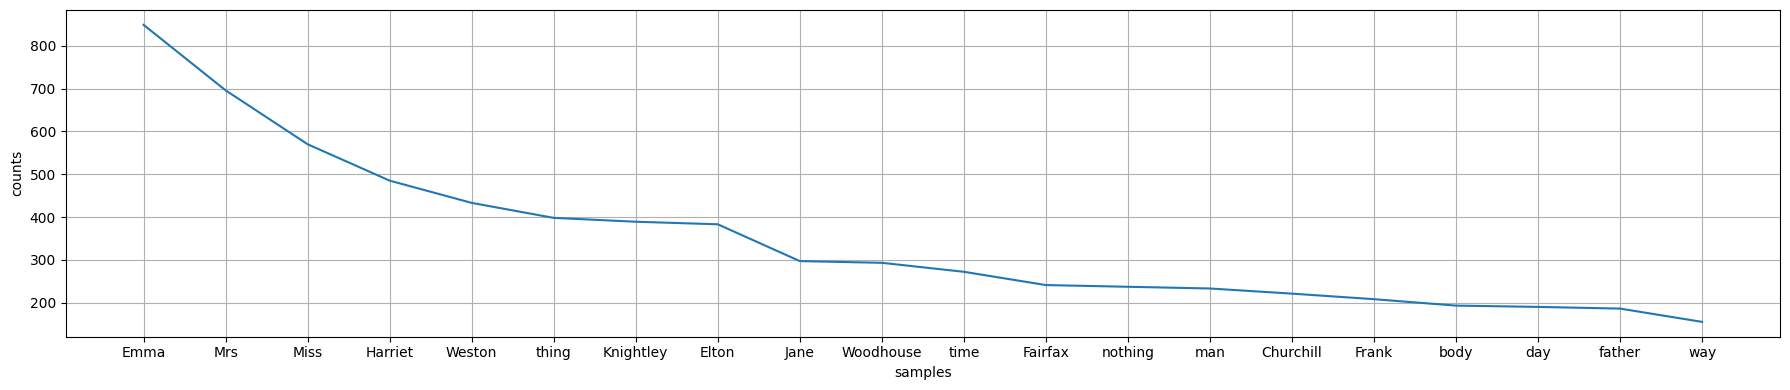

In [126]:
freqDist = emma_text.vocab()
# FreqDist
most_common = freqDist.most_common(20)
most_common
xlabel = [word for word, count in most_common] 
yvalue = [count for word, count in most_common] 
plt.figure(figsize=(18,4))
plt.plot(xlabel,yvalue,marker=None)
plt.xlabel('samples')
plt.ylabel('counts')
plt.grid()
plt.tight_layout()
plt.show()

In [127]:
emma_text.count('Emma')

849

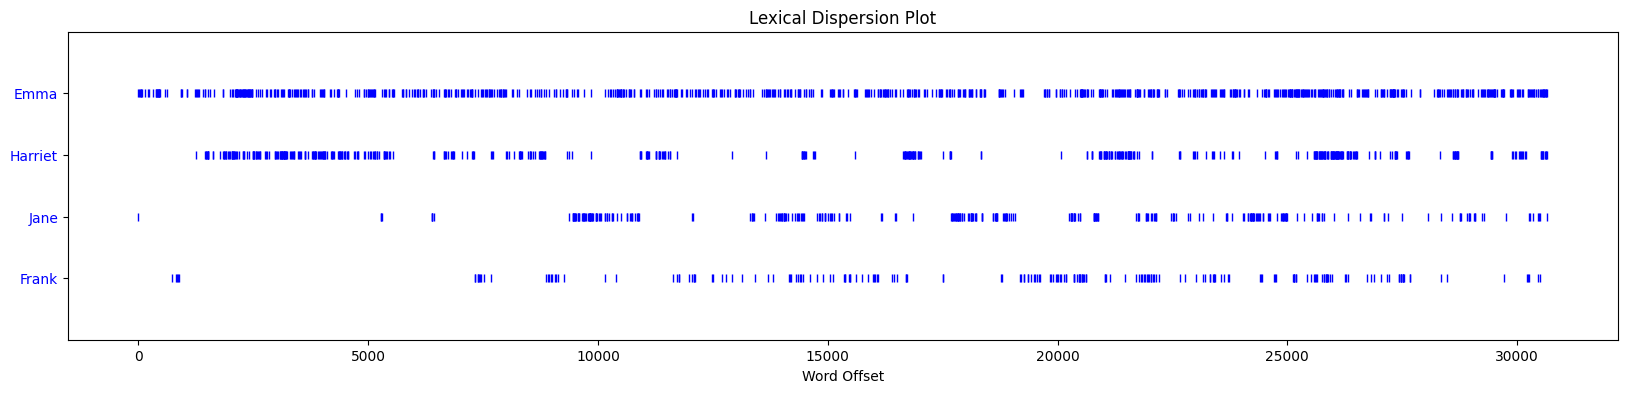

In [128]:
# Emma, Harriet, Jane, Frank emma 소설 전체에서 어디에 등장하는지 
plt.figure(figsize=(20,4))
emma_text.dispersion_plot(['Emma','Harriet','Jane','Frank'])

In [96]:
from nltk import FreqDist
tags = ['NNP','NNPS']
name_list = [word for word, tag in tagged_list if tag in tags]
name_count = FreqDist(name_list)
name_count

FreqDist({'Emma': 840, 'Mrs': 696, 'Miss': 569, 'Harriet': 484, 'Weston': 433, 'Knightley': 389, 'Elton': 382, 'Jane': 295, 'Woodhouse': 293, 'Fairfax': 241, ...})

In [97]:
for name, count in name_count.items():
    if count>150:
        print(name,':',count)

Emma : 840
Jane : 295
Woodhouse : 293
Miss : 569
Weston : 433
Mrs : 696
Hartfield : 155
Knightley : 389
Elton : 382
Churchill : 221
Frank : 208
Harriet : 484
Fairfax : 241


In [103]:

name_count_s = pd.Series(name_count)
name_count_s.sort_values(ascending=False, inplace=True)
name_count_s[name_count_s>150]

Emma         840
Mrs          696
Miss         569
Harriet      484
Weston       433
Knightley    389
Elton        382
Jane         295
Woodhouse    293
Fairfax      241
Churchill    221
Frank        208
Hartfield    155
dtype: int64

In [100]:
name_count_s = pd.Series(name_count)
name_count_s.sort_values(ascending=False, inplace=True)
name_count_s[name_count_s>150]

NameError: name 'pd' is not defined